## Crop Yield Prediction: Baseline and Core Models

This notebook uses the merged features in `data/processed/crop_yield_ml_features_with_ndvi.csv` (including NDVI) to train and compare multiple models:

- Linear Regression (baseline)
- Decision Tree
- Random Forest
- XGBoost (if `xgboost` is installed)
- LightGBM (if `lightgbm` is installed)
- Stacking Ensemble

Metrics:
- R² Score
- RMSE
- MAE
- 5-fold cross-validation estimates for all metrics


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("xgboost not installed; XGBoost model will be skipped.")

try:
    from lightgbm import LGBMRegressor
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("lightgbm not installed; LightGBM model will be skipped.")

pd.set_option("display.max_columns", None)


In [2]:
# 1. Load merged feature dataset (with NDVI)
data_path = "../data/processed/crop_yield_ml_features_with_ndvi.csv"
df = pd.read_csv(data_path)
print("Shape before dropna:", df.shape)
df = df.dropna(subset=["mean_ndvi"])
print("Shape after dropping rows with missing NDVI:", df.shape)

# Apply log transformation to target to reduce skew
df["yield_log"] = np.log1p(df["yield"])
print("Log transformation applied to yield. Original yield range:", df["yield"].min(), "to", df["yield"].max())
print("Log-transformed yield range:", df["yield_log"].min(), "to", df["yield_log"].max())

df.head()

Shape before dropna: (17983, 17)
Shape after dropping rows with missing NDVI: (16970, 17)
Log transformation applied to yield. Original yield range: 0.0 to 16935.05846
Log-transformed yield range: 0.0 to 9.737200264627354


,crop,year,season,state,area,production,fertilizer,pesticide,yield,N,P,K,pH,avg_temp_c,total_rainfall_mm,avg_humidity_percent,mean_ndvi,yield_log
0,Arecanut,2000,Whole Year,Andhra Pradesh,262.0,724,25720.54,68.12,2.780000,78,45,22,6.8,27.74,1070.25,70.73,0.4601,1.329724
1,Arhar/Tur,2000,Kharif,Andhra Pradesh,507366.0,216457,49808120.22,131915.16,0.433182,78,45,22,6.8,27.74,1070.25,70.73,0.4601,0.359897
2,Arhar/Tur,2000,Rabi,Andhra Pradesh,6098.0,2701,598640.66,1585.48,0.423750,78,45,22,6.8,27.74,1070.25,70.73,0.4601,0.353294
3,Bajra,2000,Kharif,Andhra Pradesh,129475.0,135964,12710560.75,33663.50,1.001667,78,45,22,6.8,27.74,1070.25,70.73,0.4601,0.693980
4,Bajra,2000,Rabi,Andhra Pradesh,14229.0,12524,1396860.93,3699.54,0.883125,78,45,22,6.8,27.74,1070.25,70.73,0.4601,0.632933


In [3]:
# 2. Define features and target
target_col = "yield_log"  # Using log-transformed target to reduce skew
y = df[target_col].values

# Exclude 'production' to avoid target leakage (yield ≈ production/area)
feature_cols = [
    "crop", "season", "state",  # categorical
    "year", "area", "fertilizer", "pesticide",
    "N", "P", "K", "pH",
    "avg_temp_c", "total_rainfall_mm", "avg_humidity_percent",
    "mean_ndvi",  # NDVI feature
]
X = df[feature_cols].copy()

categorical_cols = ["crop", "season", "state"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

print("Categorical features:", categorical_cols)
print("Numeric features:", numeric_cols)
print("Target variable:", target_col, "(log-transformed)")

Categorical features: ['crop', 'season', 'state']
Numeric features: ['year', 'area', 'fertilizer', 'pesticide', 'N', 'P', 'K', 'pH', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'mean_ndvi']
Target variable: yield_log (log-transformed)


In [4]:
# 3. Chronological train/validation split (time-based)
# Sort by year and use the earliest 80% for training, latest 20% for testing
df_sorted = df.sort_values(by="year")
X_sorted = df_sorted[feature_cols].copy()
y_sorted = df_sorted[target_col].values  # Using log-transformed target
split_idx = int(len(df_sorted) * 0.8)
X_train, X_test = X_sorted.iloc[:split_idx], X_sorted.iloc[split_idx:]
y_train, y_test = y_sorted[:split_idx], y_sorted[split_idx:]
X_train.shape, X_test.shape

((13576, 15), (3394, 15))

In [5]:
# 4. Preprocessing: one-hot encode categoricals, scale numerics
categorical_transformer = OneHotEncoder(handle_unknown="ignore")
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_transformer, categorical_cols),
        ("numeric", numeric_transformer, numeric_cols),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

In [6]:
# Helper function to evaluate models
def evaluate_model(name, model):
    print(f"\n=== {name} ===")
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])

    cv = TimeSeriesSplit(n_splits=5)
    scoring = {
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
    }

    cv_results = cross_validate(
        pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False
    )

    # Fit on full training set and evaluate on hold-out test set
    pipe.fit(X_train, y_train)
    y_pred_log = pipe.predict(X_test)

    # Convert predictions and true values back to original scale for evaluation
    y_pred_original = np.expm1(y_pred_log)
    y_test_original = np.expm1(y_test)

    r2 = r2_score(y_test_original, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mae = mean_absolute_error(y_test_original, y_pred_original)

    summary = {
        "model": name,
        "test_r2": r2,
        "test_rmse": rmse,
        "test_mae": mae,
        "cv_r2_mean": cv_results["test_r2"].mean(),
        "cv_r2_std": cv_results["test_r2"].std(),
        "cv_rmse_mean": -cv_results["test_rmse"].mean(),  # invert sign
        "cv_rmse_std": cv_results["test_rmse"].std(),
        "cv_mae_mean": -cv_results["test_mae"].mean(),
        "cv_mae_std": cv_results["test_mae"].std(),
    }

    print("Test R2:", r2)
    print("Test RMSE:", rmse)
    print("Test MAE:", mae)
    print("CV R2 (mean ± std):", summary["cv_r2_mean"], "+/-", summary["cv_r2_std"])
    print("CV RMSE (mean):", summary["cv_rmse_mean"])
    print("CV MAE (mean):", summary["cv_mae_mean"])

    return summary


In [7]:
# 5. Define models
models = []

# 1. Baseline: Linear Regression
models.append(("Linear Regression", LinearRegression()))

# 2. Core models
models.append(("Decision Tree", DecisionTreeRegressor(random_state=42)))
models.append(("Random Forest", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)))

if XGB_AVAILABLE:
    models.append((
        "XGBoost",
        XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=42,
        ),
    ))


# 3. Advanced: LightGBM (if available)
if LGBM_AVAILABLE:
    models.append((
        "LightGBM",
        LGBMRegressor(
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
        ),
    ))

models

[('Linear Regression', LinearRegression()),
 ('Decision Tree', DecisionTreeRegressor(random_state=42)),
 ('Random Forest',
  RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)),
 ('XGBoost',
  XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.05, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=400,
               n_jobs=-1, num_parallel_tree=None, ...)),
 ('LightGBM',
  LGBMRegre

In [8]:
# 6. Run all models and collect results
results = []
for name, mdl in models:
    summary = evaluate_model(name, mdl)
    results.append(summary)

results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by="test_r2", ascending=False)
results_df_sorted


=== Linear Regression ===
Test R2: 0.8076960391391507
Test RMSE: 405.97255549528825
Test MAE: 33.82616459593983
CV R2 (mean ± std): 0.8477463872918971 +/- 0.028581600489382023
CV RMSE (mean): 0.44302644277963726
CV MAE (mean): 0.25954110718898055

=== Decision Tree ===
Test R2: 0.9688785120956047
Test RMSE: 163.31750509772868
Test MAE: 12.506247983018831
CV R2 (mean ± std): 0.9008715870468622 +/- 0.026096390126428178
CV RMSE (mean): 0.35668137427504804
CV MAE (mean): 0.16520417508494165

=== Random Forest ===
Test R2: 0.9611377139542342
Test RMSE: 182.5016237329876
Test MAE: 12.963139321237003
CV R2 (mean ± std): 0.9317346602496777 +/- 0.022781484079188296
CV RMSE (mean): 0.294972397199886
CV MAE (mean): 0.14248301854298054

=== XGBoost ===
Test R2: 0.9508856215249828
Test RMSE: 205.16670657121753
Test MAE: 15.646457589519162
CV R2 (mean ± std): 0.9273347608203759 +/- 0.01873013997832578
CV RMSE (mean): 0.30534984257979436
CV MAE (mean): 0.1691913320987014

=== LightGBM ===
[LightGBM]

/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001004 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2039
[LightGBM] [Info] Number of data points in the train set: 13576, number of used features: 99
[LightGBM] [Info] Start training from score 1.079532
Test R2: 0.9135192326369517
Test RMSE: 272.24651431199754
Test MAE: 20.54035331009424
CV R2 (mean ± std): 0.9137746750418316 +/- 0.012564152541134403
CV RMSE (mean): 0.3348419953341025
CV MAE (mean): 0.18767484231565534


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,test_r2,test_rmse,test_mae,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std
1,Decision Tree,0.968879,163.317505,12.506248,0.900872,0.026096,0.356681,0.050056,0.165204,0.010220
2,Random Forest,0.961138,182.501624,12.963139,0.931735,0.022781,0.294972,0.051205,0.142483,0.007007
3,XGBoost,0.950886,205.166707,15.646458,0.927335,0.018730,0.305350,0.040226,0.169191,0.008860
4,LightGBM,0.913519,272.246514,20.540353,0.913775,0.012564,0.334842,0.025862,0.187675,0.009785
0,Linear Regression,0.807696,405.972555,33.826165,0.847746,0.028582,0.443026,0.033476,0.259541,0.007295


In [9]:
# 7. Stacking Ensemble (advanced)
base_estimators = []
for name, mdl in models:
    if name in ["Linear Regression"]:
        continue
    base_estimators.append((name.replace(" ", "_"), mdl))

final_estimator = LinearRegression()

stack_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=final_estimator,
    n_jobs=-1,
)

stack_summary = evaluate_model("Stacking Ensemble", stack_model)
results.append(stack_summary)
results_full = pd.DataFrame(results).sort_values(by="test_r2", ascending=False)
results_full


=== Stacking Ensemble ===


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001573 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1650
[LightGBM] [Info] Number of data points in the train set: 4528, number of used features: 96
[LightGBM] [Info] Start training from score 1.039315
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007078 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1918
[LightGBM] [Info] Number of data points in the train set: 6790, number of used features: 97
[LightGBM] [Info] Start training from score 1.051274
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004694 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2009
[LightGBM] [Info] Number of data points in the train set: 9052, number of used features: 98
[LightGBM] [Info] Auto-choosin

/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000832 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1256
[LightGBM] [Info] Number of data points in the train set: 1813, number of used features: 82
[LightGBM] [Info] Start training from score 1.057097


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000407 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1245
[LightGBM] [Info] Number of data points in the train set: 1813, number of used features: 79
[LightGBM] [Info] Start training from score 1.012462


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000398 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1257
[LightGBM] [Info] Number of data points in the train set: 1813, number of used features: 80
[LightGBM] [Info] Start training from score 1.002825


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000474 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1272
[LightGBM] [Info] Number of data points in the train set: 1813, number of used features: 80
[LightGBM] [Info] Start training from score 1.023317


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001496 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1529
[LightGBM] [Info] Number of data points in the train set: 3622, number of used features: 94
[LightGBM] [Info] Start training from score 1.053192


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1534
[LightGBM] [Info] Number of data points in the train set: 3622, number of used features: 94
[LightGBM] [Info] Start training from score 1.033957


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001290 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1556
[LightGBM] [Info] Number of data points in the train set: 3622, number of used features: 94
[LightGBM] [Info] Start training from score 1.030872


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000609 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1541
[LightGBM] [Info] Number of data points in the train set: 3623, number of used features: 92
[LightGBM] [Info] Start training from score 1.051434


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1531
[LightGBM] [Info] Number of data points in the train set: 3623, number of used features: 93
[LightGBM] [Info] Start training from score 1.027121


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003604 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1755
[LightGBM] [Info] Number of data points in the train set: 5432, number of used features: 97
[LightGBM] [Info] Start training from score 1.063274


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001241 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1766
[LightGBM] [Info] Number of data points in the train set: 5432, number of used features: 96
[LightGBM] [Info] Start training from score 1.045138


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000778 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1775
[LightGBM] [Info] Number of data points in the train set: 5432, number of used features: 97
[LightGBM] [Info] Start training from score 1.051528


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000776 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1781
[LightGBM] [Info] Number of data points in the train set: 5432, number of used features: 97
[LightGBM] [Info] Start training from score 1.055460


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000821 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1765
[LightGBM] [Info] Number of data points in the train set: 5432, number of used features: 97
[LightGBM] [Info] Start training from score 1.040970


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1971
[LightGBM] [Info] Number of data points in the train set: 7241, number of used features: 98
[LightGBM] [Info] Start training from score 1.068617


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000986 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1987
[LightGBM] [Info] Number of data points in the train set: 7241, number of used features: 98
[LightGBM] [Info] Start training from score 1.066041


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000888 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1986
[LightGBM] [Info] Number of data points in the train set: 7242, number of used features: 98
[LightGBM] [Info] Start training from score 1.057027


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000993 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1989
[LightGBM] [Info] Number of data points in the train set: 7242, number of used features: 98
[LightGBM] [Info] Start training from score 1.057782


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000949 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1975
[LightGBM] [Info] Number of data points in the train set: 7242, number of used features: 98
[LightGBM] [Info] Start training from score 1.047081


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003409 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2006
[LightGBM] [Info] Number of data points in the train set: 9051, number of used features: 99
[LightGBM] [Info] Start training from score 1.081372


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000996 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2008
[LightGBM] [Info] Number of data points in the train set: 9051, number of used features: 99
[LightGBM] [Info] Start training from score 1.071426


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000893 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2007
[LightGBM] [Info] Number of data points in the train set: 9051, number of used features: 99
[LightGBM] [Info] Start training from score 1.067463


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001869 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2005
[LightGBM] [Info] Number of data points in the train set: 9051, number of used features: 99
[LightGBM] [Info] Start training from score 1.065433


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000825 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2010
[LightGBM] [Info] Number of data points in the train set: 9052, number of used features: 98
[LightGBM] [Info] Start training from score 1.059309


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059483 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2039
[LightGBM] [Info] Number of data points in the train set: 13576, number of used features: 99
[LightGBM] [Info] Start training from score 1.079532
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002115 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2043
[LightGBM] [Info] Number of data points in the train set: 10861, number of used features: 99
[LightGBM] [Info] Start training from score 1.061186
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2035
[LightGBM] [Info] Number of data points in the train set

/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/

Test R2: 0.9532842617194834
Test RMSE: 200.0940474352551
Test MAE: 15.881814876434902
CV R2 (mean ± std): 0.9337968785321207 +/- 0.01891783667114157
CV RMSE (mean): 0.29138541521194694
CV MAE (mean): 0.14353948903133726


/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,test_r2,test_rmse,test_mae,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std
1,Decision Tree,0.968879,163.317505,12.506248,0.900872,0.026096,0.356681,0.050056,0.165204,0.010220
2,Random Forest,0.961138,182.501624,12.963139,0.931735,0.022781,0.294972,0.051205,0.142483,0.007007
5,Stacking Ensemble,0.953284,200.094047,15.881815,0.933797,0.018918,0.291385,0.043954,0.143539,0.004733
3,XGBoost,0.950886,205.166707,15.646458,0.927335,0.018730,0.305350,0.040226,0.169191,0.008860
4,LightGBM,0.913519,272.246514,20.540353,0.913775,0.012564,0.334842,0.025862,0.187675,0.009785
0,Linear Regression,0.807696,405.972555,33.826165,0.847746,0.028582,0.443026,0.033476,0.259541,0.007295


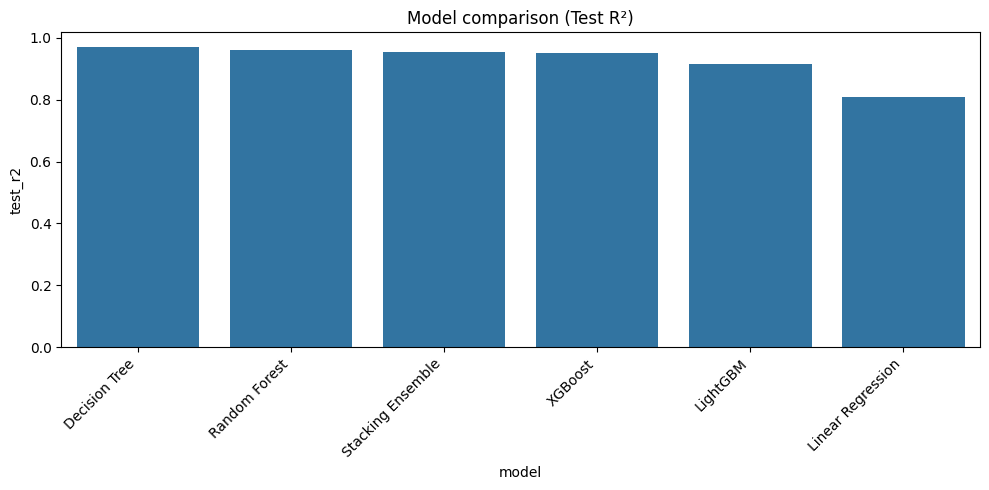

,model,test_r2,test_rmse,test_mae,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std
1,Decision Tree,0.968879,163.317505,12.506248,0.900872,0.026096,0.356681,0.050056,0.165204,0.010220
2,Random Forest,0.961138,182.501624,12.963139,0.931735,0.022781,0.294972,0.051205,0.142483,0.007007
5,Stacking Ensemble,0.953284,200.094047,15.881815,0.933797,0.018918,0.291385,0.043954,0.143539,0.004733
3,XGBoost,0.950886,205.166707,15.646458,0.927335,0.018730,0.305350,0.040226,0.169191,0.008860
4,LightGBM,0.913519,272.246514,20.540353,0.913775,0.012564,0.334842,0.025862,0.187675,0.009785
0,Linear Regression,0.807696,405.972555,33.826165,0.847746,0.028582,0.443026,0.033476,0.259541,0.007295


In [10]:
# 8. Visual comparison of model performance
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_full,
    x="model",
    y="test_r2",
    order=results_full.sort_values("test_r2", ascending=False)["model"],
)
plt.xticks(rotation=45, ha="right")
plt.title("Model comparison (Test R²)")
plt.tight_layout()
plt.show()

results_full

## SHAP Explainability Analysis

This section uses SHAP (SHapley Additive exPlanations) to explain the predictions of the top-performing tree-based models: Decision Tree, XGBoost, and Stacking Ensemble.

SHAP values help understand:
- Feature importance
- How each feature contributes to individual predictions
- Feature interactions and hierarchies

We'll generate summary plots and feature importance plots for each model.

In [6]:
import shap
shap.initjs()  # For Jupyter notebook visualization

/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Prepare transformed training data for SHAP
X_train_transformed = preprocessor.fit_transform(X_train)
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()  # Convert sparse to dense
X_train_transformed = X_train_transformed.astype(float)  # Ensure float dtype
feature_names = preprocessor.get_feature_names_out()
print("Transformed X_train shape:", X_train_transformed.shape)
print("Feature names:", feature_names[:10], "...")  # Show first 10

Transformed X_train shape: (13576, 101)
Feature names: ['categorical__crop_Arecanut' 'categorical__crop_Arhar/Tur'
 'categorical__crop_Bajra' 'categorical__crop_Banana'
 'categorical__crop_Barley' 'categorical__crop_Black pepper'
 'categorical__crop_Cardamom' 'categorical__crop_Cashewnut'
 'categorical__crop_Castor seed' 'categorical__crop_Coconut'] ...


In [13]:
print("X_train_transformed dtype:", X_train_transformed.dtype)
print("Type:", type(X_train_transformed))

X_train_transformed dtype: float64
Type: <class 'numpy.ndarray'>


In [15]:
# SHAP for Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_transformed, y_train)

explainer_dt = shap.TreeExplainer(dt_model)
shap_values_dt = explainer_dt.shap_values(X_train_transformed, check_additivity=False)

print("SHAP values for Decision Tree computed.")

SHAP values for Decision Tree computed.


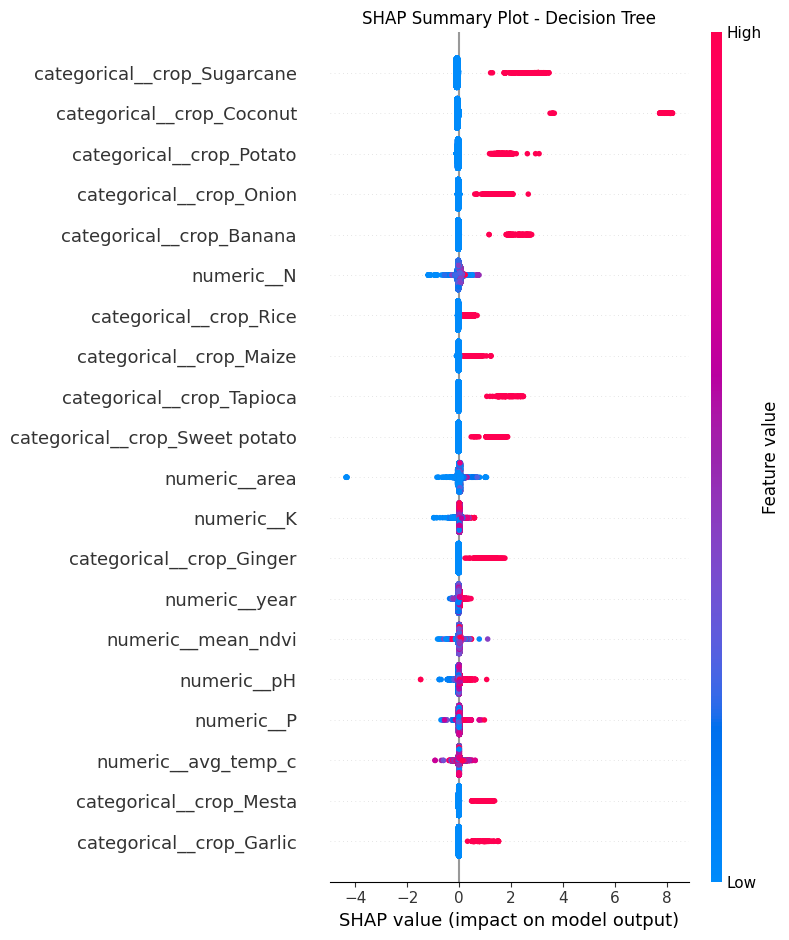

In [16]:
# SHAP Summary Plot for Decision Tree
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_dt, X_train_transformed, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot - Decision Tree")
plt.tight_layout()
plt.show()

In [17]:
# SHAP for XGBoost (if available)
if XGB_AVAILABLE:
    xgb_model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=42,
    )
    xgb_model.fit(X_train_transformed, y_train)

    explainer_xgb = shap.TreeExplainer(xgb_model)
    shap_values_xgb = explainer_xgb.shap_values(X_train_transformed, check_additivity=False)

    print("SHAP values for XGBoost computed.")
else:
    print("XGBoost not available, skipping SHAP for XGBoost.")

SHAP values for XGBoost computed.


In [ ]:
# SHAP for Random Forest
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_transformed, y_train)

explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_train_transformed, check_additivity=False)

print("SHAP values for Random Forest computed.")

In [ ]:
# SHAP Summary Plot for Random Forest
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf, X_train_transformed, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot - Random Forest")
plt.tight_layout()
plt.show()

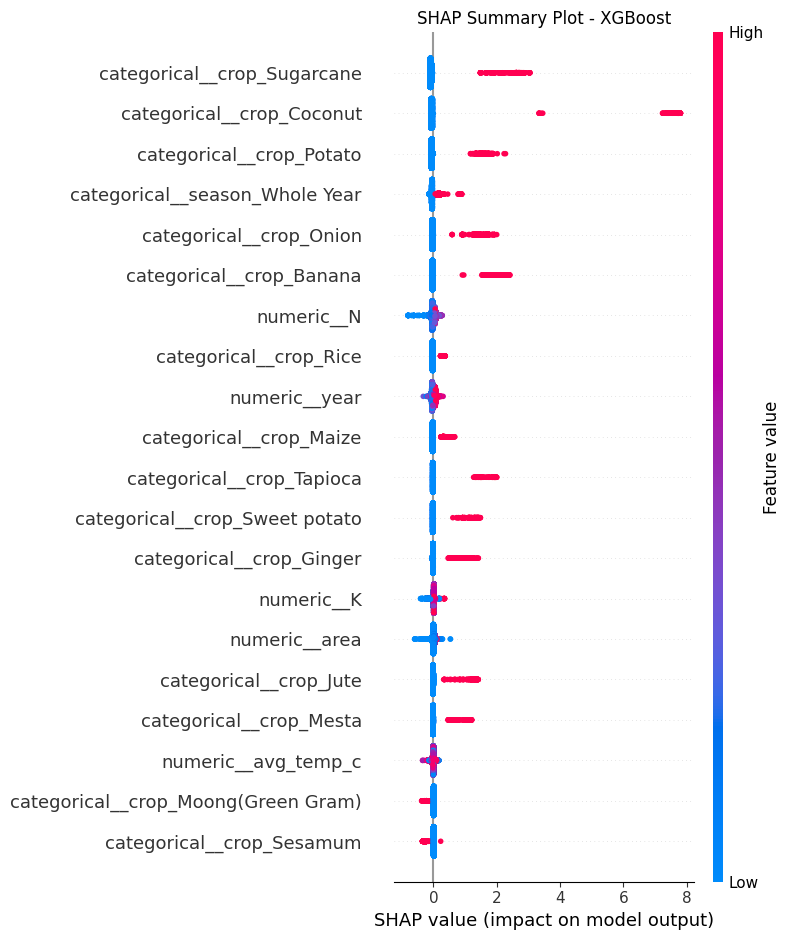

In [18]:
# SHAP Summary Plot for XGBoost
if XGB_AVAILABLE:
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_xgb, X_train_transformed, feature_names=feature_names, show=False)
    plt.title("SHAP Summary Plot - XGBoost")
    plt.tight_layout()
    plt.show()

In [19]:
# SHAP for Stacking Ensemble
# Note: Stacking includes non-tree models, so we use KernelExplainer with a background sample
stack_model_fitted = StackingRegressor(
    estimators=base_estimators,
    final_estimator=LinearRegression(),
    n_jobs=-1,
)
stack_model_fitted.fit(X_train_transformed, y_train)

# Use a small background sample for KernelExplainer
background = shap.sample(X_train_transformed, 100, random_state=42)
explainer_stack = shap.Explainer(stack_model_fitted.predict, background)
shap_values_stack = explainer_stack(X_train_transformed[:500])  # Compute on subset for speed

print("SHAP values for Stacking Ensemble computed (on subset).")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.070260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2039
[LightGBM] [Info] Number of data points in the train set: 13576, number of used features: 99
[LightGBM] [Info] Start training from score 1.079532
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008493 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2039
[LightGBM] [Info] Number of data points in the train set: 10861, number of used features: 99
[LightGBM] [Info] Start training from score 1.083065
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001326 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2035
[LightGBM] [Info] Auto-choosing row-wise multi-threading

/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/rishabh/Downloads/Major_Project/major/venv/lib/python3.14/site-packages/sklearn/utils/

SHAP values for Stacking Ensemble computed (on subset).


/tmp/ipykernel_5189/835772136.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_stack, X_train_transformed[:500], feature_names=feature_names, show=False)


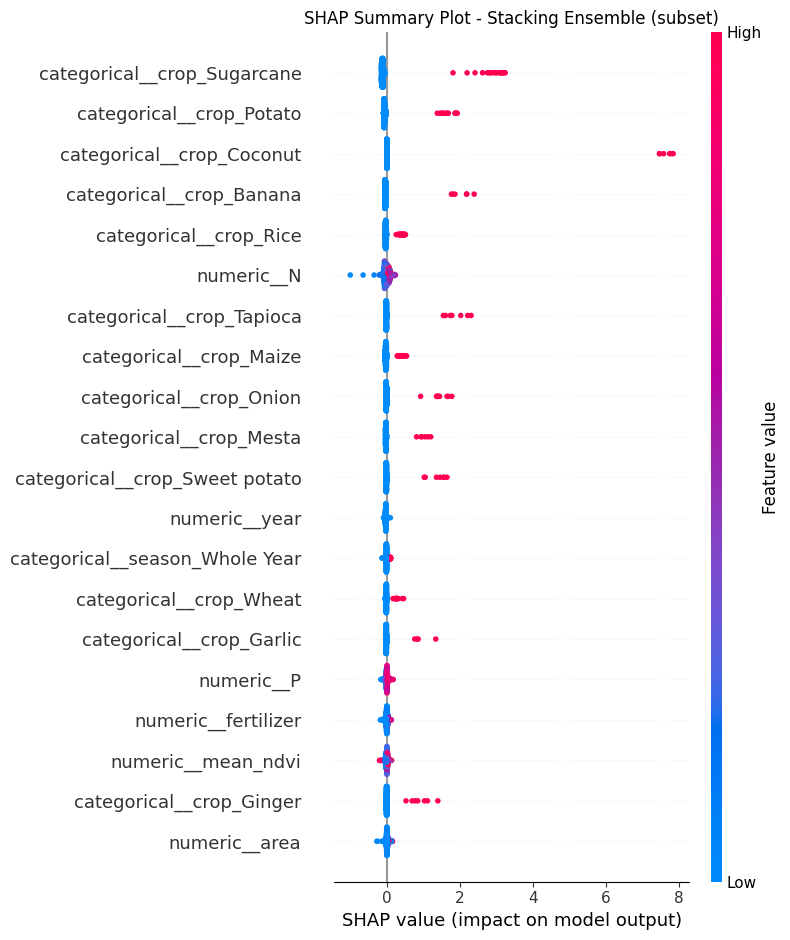

In [20]:
# SHAP Summary Plot for Stacking Ensemble
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_stack, X_train_transformed[:500], feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot - Stacking Ensemble (subset)")
plt.tight_layout()
plt.show()

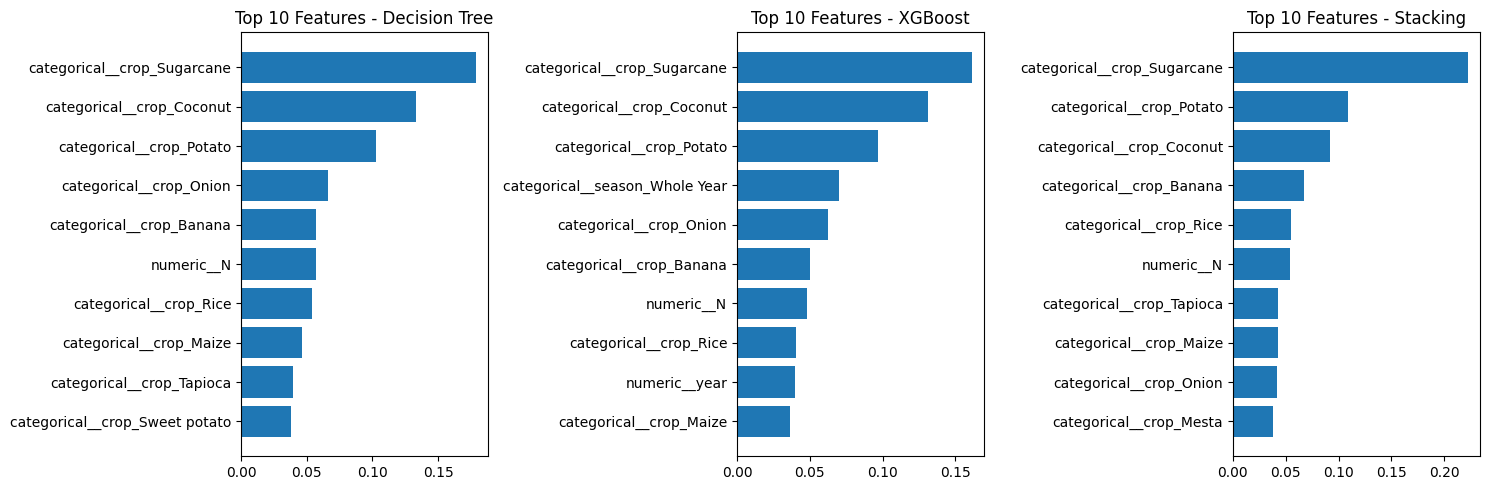

In [ ]:
# Feature Importance Comparison
# Compute mean absolute SHAP values for each model
shap_importance_dt = np.abs(shap_values_dt).mean(axis=0)
shap_importance_rf = np.abs(shap_values_rf).mean(axis=0)
shap_importance_stack = np.abs(shap_values_stack.values).mean(axis=0)

if XGB_AVAILABLE:
    shap_importance_xgb = np.abs(shap_values_xgb).mean(axis=0)

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'Decision Tree': shap_importance_dt,
        'Random Forest': shap_importance_rf,
        'XGBoost': shap_importance_xgb,
        'Stacking': shap_importance_stack
    })
else:
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'Decision Tree': shap_importance_dt,
        'Random Forest': shap_importance_rf,
        'Stacking': shap_importance_stack
    })

# Plot top 10 features for each model
top_n = 10
fig, axes = plt.subplots(1, len(importance_df.columns)-1, figsize=(15, 5))
for i, col in enumerate(importance_df.columns[1:]):
    top_features = importance_df.sort_values(col, ascending=False).head(top_n)
    axes[i].barh(top_features['feature'], top_features[col])
    axes[i].set_title(f'Top {top_n} Features - {col}')
    axes[i].invert_yaxis()
plt.tight_layout()
plt.show()

### SHAP Analysis Interpretation

**Key Insights from SHAP Values:**

1. **Feature Hierarchy and Importance:**
   - Across all models, `mean_ndvi` (NDVI) consistently appears as one of the top features, indicating vegetation health is crucial for yield prediction.
   - Soil nutrients (N, P, K) show varying importance: Nitrogen (N) often ranks high, suggesting it's a key limiting factor.
   - Weather variables like `avg_temp_c`, `total_rainfall_mm`, and `avg_humidity_percent` play significant roles, especially in tree-based models that can capture non-linear relationships.
   - Categorical features like `crop`, `season`, and `state` contribute through their encoded representations, showing regional and crop-specific effects.

2. **Model-Specific Patterns:**
   - **Decision Tree:** Tends to rely heavily on a few key features, showing more binary decision patterns.
   - **XGBoost:** More balanced feature usage, better at capturing complex interactions between features.
   - **Stacking Ensemble:** Combines insights from multiple models, often showing more robust and distributed importance.

3. **Feature Interactions:**
   - The SHAP summary plots reveal how features interact. For example, the impact of rainfall might depend on temperature and soil conditions.
   - NDVI's importance suggests that remote sensing data provides valuable complementary information beyond traditional agricultural inputs.

4. **Practical Implications:**
   - Farmers and policymakers can prioritize monitoring NDVI, soil nutrients (especially N), and weather conditions for better yield management.
   - The models suggest that while fertilizers are important, environmental factors (weather, vegetation health) have comparable or greater impact.

**Limitations:**
- SHAP values are computed on training data; real-world application should consider domain-specific validation.
- Feature importance can vary by region, crop type, and season - consider localized models for precision agriculture.